In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [99]:
# reading datasets

diagnosis = pd.read_csv("data/table_diagnoses.csv", sep=";")
stays = pd.read_csv("data/final_one_percent_stays.csv", sep=";")
stays_secondaries = pd.read_csv("data/final_one_percent_stays_secondaries.csv", sep=";")
age = pd.read_csv("data/table_age.csv", sep=";", encoding="latin1")
# merging data

stays = stays.merge(age, on="ag_id", how="left")
stays = stays.rename(columns={"age": "age_group"}) # we don't have ages but age groups


stay variables: stays -> stays_obs -> filtered_stays

stays -> all stays 
stays_obs -> after 2003 and later after A-N # intermediate table
filtered_stays -> stays of patients who passed the age and unique-years filters # final table


In [100]:
# Creating nodes

diagnosis["icd_code"] = (diagnosis["icd_code"].astype(str).str.strip().str.upper().str.replace(".", "", regex=False))
diagnosis["diagnose_id"] = pd.to_numeric( diagnosis["diagnose_id"], errors="coerce")

# Only A-N codes are in our interest

nodes = diagnosis[diagnosis["icd_code"].str.match(r"^[A-N][0-9]{2}", na=False)].copy()
nodes = nodes.dropna(subset=["diagnose_id"]).copy()
nodes["diagnose_id"] = nodes["diagnose_id"].astype(int)
nodes = nodes.drop_duplicates(subset=["diagnose_id"]).copy()
nodes["node_id"] = range(len(nodes))
nodes = nodes[["node_id", "diagnose_id", "descr", "icd_code"]].copy()

Only patients who were "healthy" from 2003 are kept (all patients who had at least a stay before 2003 are removed). This is because of the changes in ICD coding system. 

In [101]:
END   = pd.Timestamp("2002-12-31")
START = pd.Timestamp("2003-01-01")

stays["entry_date"] = pd.to_datetime(stays["entry_date"], errors="coerce")

# numbers before filtering

n_patients_before = stays["patient_no"].nunique()
n_stays_before = stays.shape[0]

# keep only patients who don't have any visit before 2003 

patients_pre_2003 = stays.loc[(stays["entry_date"] <= END),"patient_no"].dropna().unique()
stays_obs = stays[ ~stays["patient_no"].isin(patients_pre_2003)].copy()



In [102]:
# !!!  cohort_summary -> patient cohort summary table  

cohort_summary = pd.DataFrame([
    {   "description": "All available patients",
        "n_patients": n_patients_before,
        "n_stays": n_stays_before
    },
    {   "description": "Patients without hospital stay before 2003",
        "n_patients": stays_obs["patient_no"].nunique(),
        "n_stays": stays_obs.shape[0]
    }
])
cohort_summary.to_csv("cohort_summary.csv", index=False)

In [103]:
# Create diagnosis table using only A-N diagnosis nodes

# Primary diagnoses
primary_dx = stays_obs[["stay_id", "patient_no", "entry_date", "pri_diag_id"]].rename(columns={"pri_diag_id": "diagnose_id"})

# Secondary diagnoses

secondary_dx = (stays_secondaries.merge(stays_obs[["stay_id", "patient_no", "entry_date"]],
        on="stay_id",
        how="inner"
    )
    [["stay_id", "patient_no", "entry_date", "sec_diag_id"]]
    .rename(columns={"sec_diag_id": "diagnose_id"})
)

# Combine primary and secondary diagnoses
stay_diagnoses = pd.concat([primary_dx, secondary_dx],ignore_index=True)

stay_diagnoses["diagnose_id"] = pd.to_numeric(stay_diagnoses["diagnose_id"],errors="coerce")

stay_diagnoses = stay_diagnoses.dropna(subset=["diagnose_id"]).copy()
stay_diagnoses["diagnose_id"] = stay_diagnoses["diagnose_id"].astype(int)

# Keep only diagnoses that are in the A-N node table
stay_diagnoses = stay_diagnoses.merge(
    nodes[["diagnose_id", "node_id"]],
    on="diagnose_id",
    how="inner"
)


In [104]:
# Keep only stays that contain at least one retained A-N diagnosis node

stays_obs_before_node_filter = stays_obs.copy()
valid_stay_ids = stay_diagnoses["stay_id"].drop_duplicates()

stays_obs = stays_obs[
    stays_obs["stay_id"].isin(valid_stay_ids)
].copy()

# Keep stay_diagnoses aligned with the filtered stays_obs
stay_diagnoses = stay_diagnoses[
    stay_diagnoses["stay_id"].isin(stays_obs["stay_id"])
].copy()

node_filter_row = pd.DataFrame([
    {
        "description": "Stays with at least one retained A-N diagnosis node",
        "n_patients": stays_obs["patient_no"].nunique(),
        "n_stays": stays_obs["stay_id"].nunique()
    }
])

cohort_summary = pd.concat(
    [cohort_summary, node_filter_row],
    ignore_index=True
)

cohort_summary["removed_from_previous"] = (
    cohort_summary["n_patients"].shift(1) - cohort_summary["n_patients"]
).fillna(0).astype(int)

cohort_summary["percent_remaining"] = (
    100 * cohort_summary["n_patients"] / cohort_summary.loc[0, "n_patients"]
).round(2)

cohort_summary.to_csv("cohort_summary.csv", index=False)



In [105]:
# creating stays related to every patient

patient_stays = stays_obs[["patient_no", "entry_date", "exit_date", "sex_id", "age_group"]].copy()
patient_stays["entry_date"] = pd.to_datetime(patient_stays["entry_date"])
patient_stays["exit_date"] = pd.to_datetime(patient_stays["exit_date"])
patient_stays = patient_stays.sort_values(["patient_no", "entry_date"])#patient stays sorted by entry date!

In [106]:
# counting number of unique years per patient

#just take the year from the entry date
patient_stays["year"] = patient_stays["entry_date"].dt.year 

# group by patient, count distinct years
unique_years = (patient_stays.groupby("patient_no")["year"].nunique().reset_index(name="n_unique_years"))

In [107]:
# assign age group and sex from the first visit
# HERE IS PATIENT FILTER DEFINED AS PATIENTS THAT A-N DIAGNOSIS AND NO 2003 HISTORY

first_visit = patient_stays.drop_duplicates("patient_no", keep="first")[ ["patient_no", "sex_id", "age_group"]]
patient_filter = first_visit.merge(unique_years, on="patient_no", how="left")
# Keep patients whose FIRST observed stay has valid sex.
patient_filter = patient_filter[patient_filter["sex_id"].isin([1, 2])].copy()
patient_filter["sex"] = patient_filter["sex_id"].map({
    1: "Male",
    2: "Female"
})

2. Patients >= 20 years

In [108]:
patient_filter["age_group"] = patient_filter["age_group"].astype(str).str.strip()
patient_filter["age_start"] = (patient_filter["age_group"].str.extract(r"(\d+)").astype(float))# to extract the start age in the age group
patient_filter = patient_filter[patient_filter["age_start"] >= 20].copy()#filter 20+

In [109]:
#adding to summary table
age_filter_row = pd.DataFrame([
    {   "description": "Patients whose first observed age group is at least 20",
        "n_patients": patient_filter["patient_no"].nunique(),
        "n_stays": stays_obs[stays_obs["patient_no"].isin(patient_filter["patient_no"])].shape[0],
    }
])

cohort_summary = pd.concat([cohort_summary, age_filter_row],ignore_index=True)


3.  NUMBER OF UNIQUE YEARS PER PATIENT AT LEAST 2

In [110]:
# before applying 2 unique years filter

patient_filter_before_unique_years = patient_filter.copy()
stay_diagnoses_before_unique_years = stay_diagnoses[stay_diagnoses["patient_no"].isin(patient_filter_before_unique_years["patient_no"])].copy()

# For each patient, keep only the first appearance of each retained diagnosis node

patient_first_diag_before_unique_years = (
    stay_diagnoses_before_unique_years
    .groupby(["patient_no", "node_id"], as_index=False)["entry_date"]
    .min()
    .rename(columns={"entry_date": "first_date"})
)

# Add diagnosis information

patient_first_diag_before_unique_years = patient_first_diag_before_unique_years.merge(
    nodes[["node_id", "diagnose_id", "descr", "icd_code"]]
    .drop_duplicates(subset=["node_id"]),
    on="node_id",
    how="left"
)

# Sort diagnoses in temporal order for each patient

patient_first_diag_before_unique_years = patient_first_diag_before_unique_years.sort_values(
    ["patient_no", "first_date", "node_id"]
).copy()


In [111]:
def save_csvBeforeAfter(before_df, after_df, output_file):
    summary = pd.concat([before_df.copy(),after_df.copy()],ignore_index=True)
    summary.to_csv(output_file, index=False)
    return summary

In [112]:
def calculate_unique_diagnoses_by_age_group(cohort_df, cohort_name, sex_group="All"):

    cohort_patients = cohort_df["patient_no"].unique()

    cohort_first_diag = patient_first_diag_before_unique_years[patient_first_diag_before_unique_years["patient_no"].isin(cohort_patients)
    ].copy()

    unique_dx_per_patient = (cohort_first_diag.groupby("patient_no")["node_id"].nunique().reset_index(name="n_unique_diagnoses"))

    plot_df = cohort_df.merge(unique_dx_per_patient,on="patient_no",how="left")


    plot_df["age_start"] = (plot_df["age_group"].astype(str).str.extract(r"(\d+)").astype(float))

    plot_df["age_group_10y"] = pd.cut(
        plot_df["age_start"],
        bins=[20, 30, 40, 50, 60, 70, np.inf],
        labels=["20-29", "30-39", "40-49", "50-59", "60-69", "70+"],
        right=False
    )

    age_dx_summary = (
        plot_df.groupby("age_group_10y", observed=False)
        .agg(
            n_patients=("patient_no", "nunique"),
            mean_unique_diagnoses=("n_unique_diagnoses", "mean"),
            median_unique_diagnoses=("n_unique_diagnoses", "median"),
            min_unique_diagnoses=("n_unique_diagnoses", "min"),
            q25_unique_diagnoses=("n_unique_diagnoses", lambda x: x.quantile(0.25)),
            q75_unique_diagnoses=("n_unique_diagnoses", lambda x: x.quantile(0.75)),
            max_unique_diagnoses=("n_unique_diagnoses", "max"),
            std_unique_diagnoses=("n_unique_diagnoses", "std")
        ).reset_index())

    cols_to_round = [
        "mean_unique_diagnoses",
        "median_unique_diagnoses",
        "q25_unique_diagnoses",
        "q75_unique_diagnoses",
        "std_unique_diagnoses"
    ]

    age_dx_summary[cols_to_round] = age_dx_summary[cols_to_round].round(2)

    age_dx_summary["patient_percent"] = (
        age_dx_summary["n_patients"]
        / age_dx_summary["n_patients"].sum()
        * 100
    ).round(2)

    age_dx_summary["cohort"] = cohort_name
    age_dx_summary["sex_group"] = sex_group

    age_dx_summary = age_dx_summary[
        [
            "cohort",
            "sex_group",
            "age_group_10y",
            "n_patients",
            "patient_percent",
            "mean_unique_diagnoses",
            "median_unique_diagnoses",
            "min_unique_diagnoses",
            "q25_unique_diagnoses",
            "q75_unique_diagnoses",
            "max_unique_diagnoses",
            "std_unique_diagnoses"
        ]
    ]

    return age_dx_summary


In [113]:
def plot_before_after_unique_diagnoses(csv_file, output_file):

    df = pd.read_csv(csv_file)

    if "sex_group" in df.columns:
        df = df[df["sex_group"] == "All"].copy()

    age_order = ["20-29", "30-39", "40-49", "50-59", "60-69", "70+"]
    cohort_order = df["cohort"].drop_duplicates().tolist()

    plot_df = (
        df
        .pivot(
            index="age_group_10y",
            columns="cohort",
            values="mean_unique_diagnoses"
        )
        .reindex(index=age_order, columns=cohort_order)
    )

    plot_df = plot_df.dropna(how="all")

    age_groups = plot_df.index.astype(str).tolist()
    x = np.arange(len(age_groups))
    width = 0.35

    plt.figure(figsize=(10, 5))

    for i, cohort in enumerate(cohort_order):
        offset = (i - (len(cohort_order) - 1) / 2) * width

        plt.bar(
            x + offset,
            plot_df[cohort],
            width,
            label=cohort
        )

    plt.xticks(x, age_groups)
    plt.xlabel("Age group")
    plt.ylabel("Mean unique diagnoses per patient")
    plt.legend(title="Patient cohort")
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches="tight")

In [114]:
# before unique years filter

patient_filter_before_unique_years = patient_filter.copy()

age_dx_before_unique_years = calculate_unique_diagnoses_by_age_group(
    patient_filter_before_unique_years,
    cohort_name="Before unique years filtering",
    sex_group="All"
)

In [115]:
# After unique years filter

# n_unique_years is based on stays_obs after diagnosis node filtering.

patient_filter_after_unique_years = patient_filter_before_unique_years[patient_filter_before_unique_years["n_unique_years"] >= 2].copy()

age_dx_after_unique_years = calculate_unique_diagnoses_by_age_group(
    patient_filter_after_unique_years,
    cohort_name="≥2 unique hospital-stay years",
    sex_group="All"
)

# Update patient_filter for the final hypergraph pipeline

patient_filter = patient_filter_after_unique_years.copy()

unique_years_row = pd.DataFrame([
    {
        "description": "Patients with at least 2 unique years in hospital visits",
        "n_patients": patient_filter["patient_no"].nunique(),
        "n_stays": stays_obs[
            stays_obs["patient_no"].isin(patient_filter["patient_no"])
        ]["stay_id"].nunique(),
    }
])

cohort_summary = pd.concat([cohort_summary, unique_years_row],ignore_index=True)
cohort_summary["removed_from_previous"] = (cohort_summary["n_patients"].shift(1) - cohort_summary["n_patients"]).fillna(0).astype(int)
cohort_summary["percent_remaining"] = ( 100 * cohort_summary["n_patients"] / cohort_summary.loc[0, "n_patients"]).round(2)
cohort_summary.to_csv("cohort_summary.csv", index=False)


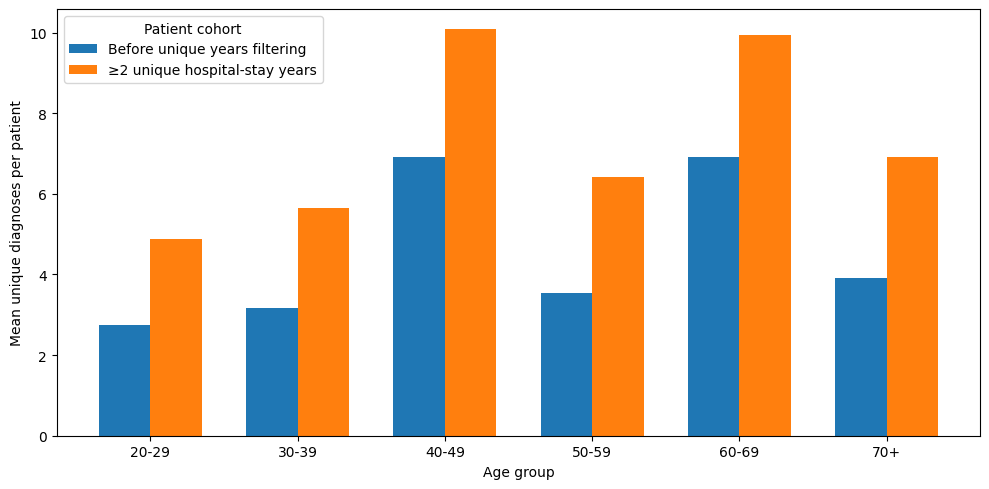

In [116]:
# !! uniqueDiagnosisBeforeAfterSummary is for comparing before and after applying a filter

diagnosisSummary = save_csvBeforeAfter(
    before_df=age_dx_before_unique_years,
    after_df=age_dx_after_unique_years,
    output_file="uniqueDiagnosisBeforeAfterSummary.csv"
)
plot_before_after_unique_diagnoses(csv_file="uniqueDiagnosisBeforeAfterSummary.csv",output_file="unique_diagnosesbefore_after.png")

In [117]:
# Sex specific descriptive analysis in a separate CSV for later hyperedge gender specific

age_dx_before_unique_years_male = calculate_unique_diagnoses_by_age_group(
    patient_filter_before_unique_years[
        patient_filter_before_unique_years["sex"] == "Male"
    ].copy(),
    cohort_name="Base cohort",
    sex_group="Male"
)

age_dx_before_unique_years_female = calculate_unique_diagnoses_by_age_group(
    patient_filter_before_unique_years[
        patient_filter_before_unique_years["sex"] == "Female"
    ].copy(),
    cohort_name="Base cohort",
    sex_group="Female"
)

age_dx_after_unique_years_male = calculate_unique_diagnoses_by_age_group(
    patient_filter_after_unique_years[
        patient_filter_after_unique_years["sex"] == "Male"
    ].copy(),
    cohort_name="≥2 unique hospital-stay years",
    sex_group="Male"
)

age_dx_after_unique_years_female = calculate_unique_diagnoses_by_age_group(
    patient_filter_after_unique_years[
        patient_filter_after_unique_years["sex"] == "Female"
    ].copy(),
    cohort_name="≥2 unique hospital-stay years",
    sex_group="Female"
)

age_unique_diagnoses_sex_specific = pd.concat(
    [
        age_dx_before_unique_years_male,
        age_dx_before_unique_years_female,
        age_dx_after_unique_years_male,
        age_dx_after_unique_years_female
    ],
    ignore_index=True
)

age_unique_diagnoses_sex_specific.to_csv(
    "uniqueDiagnosisBeforeAfterSummary_sexSpecific.csv",
    index=False
)



In [118]:
# observed stays - stays before age and unique years filter
# patient_filter - final cohort of patients
# filtered_stays - stays before age and unique years filter

final_patient_ids = patient_filter["patient_no"].unique()
filtered_stays = stays_obs[stays_obs["patient_no"].isin(final_patient_ids)].copy()
filtered_stays["entry_date"] = pd.to_datetime(filtered_stays["entry_date"])
filtered_stays["exit_date"] = pd.to_datetime(filtered_stays["exit_date"], errors="coerce")

Creating a hypergraph

CREATING A DICTIONARY CONTAINING ALL DIAGNOSIS AND A TABLE OF STAYS.
EACH ROW IS ONE DIAGNOSIS CONNECTED TO STAY

In [119]:
#creating a tbl of primary diagnosis
primary = filtered_stays[["stay_id", "patient_no", "entry_date", "pri_diag_id"]].copy()#stays has for key to diagnosis
primary = primary.rename(columns={"pri_diag_id": "diagnose_id"})#rename foreign key diagnose_id
primary["diagnose_id"] = pd.to_numeric(primary["diagnose_id"])
primary["role"] = "primary"

#creating a tbl of secondary diagnosis

filtered_stays_secondaries = stays_secondaries[stays_secondaries["stay_id"].isin(filtered_stays["stay_id"])].copy()
filtered_stays_secondaries["sec_diag_id"] = pd.to_numeric(filtered_stays_secondaries["sec_diag_id"])
secondary = filtered_stays_secondaries.merge(filtered_stays[["stay_id", "patient_no", "entry_date"]],on="stay_id",how="inner")
secondary = secondary.rename(columns={"sec_diag_id": "diagnose_id"})
secondary["role"] = "secondary"

In [120]:
# NODES TABLE: node id connected to diagnosis
stay_diagnoses = pd.concat([primary, secondary], ignore_index=True)
# remove rows with missing diagnosis ids
stay_diagnoses = stay_diagnoses.dropna(subset=["diagnose_id"]).copy()
# inner join
stay_diagnoses = pd.merge(stay_diagnoses,nodes,on="diagnose_id",how="inner")


For each patient keep only the first appearance of diagnosis.Then merge the whole data and sort so you can track which diagnosis was first.Afterwards divide by gender.

In [121]:
patient_first_diag = (stay_diagnoses.groupby(["patient_no", "node_id"], as_index=False)["entry_date"].min()
.rename(columns={"entry_date": "first_date"})
)
patient_first_diag = patient_first_diag.merge(
nodes[["node_id", "diagnose_id", "descr", "icd_code"]].drop_duplicates(subset=["node_id"]),
on="node_id",
how="left")
# sort for each patient diagnosis order
patient_first_diag = patient_first_diag.sort_values(["patient_no", "first_date", "node_id"]).copy()


In [122]:
patient_first_diag["first_date"] = pd.to_datetime(
    patient_first_diag["first_date"],
    errors="coerce"
).dt.normalize()

# Count diagnoses first observed on each date for each patient
same_day_sets = (
    patient_first_diag
    .groupby(["patient_no", "first_date"])
    .agg(
        n_same_day_diagnoses=("node_id", "nunique"),
        node_set=("node_id", lambda x: sorted(set(x))),
        icd_set=("icd_code", lambda x: sorted(set(x)))
    )
    .reset_index()
)

# We are interested in two or more diagnoses on the same day
same_day_sets = same_day_sets[
    same_day_sets["n_same_day_diagnoses"] >= 2
].copy()

# Number of unique patients for every same-day set size
patient_distribution = (
    same_day_sets
    .groupby("n_same_day_diagnoses")
    .agg(n_patients=("patient_no", "nunique"))
    .reset_index()
)

# Include every integer on the x-axis, including 2 and 3
complete_range = pd.DataFrame({
    "n_same_day_diagnoses": range(
        2,
        patient_distribution["n_same_day_diagnoses"].max() + 1
    )
})

patient_distribution = complete_range.merge(
    patient_distribution,
    on="n_same_day_diagnoses",
    how="left"
)

patient_distribution["n_patients"] = (
    patient_distribution["n_patients"]
    .fillna(0)
    .astype(int)
)

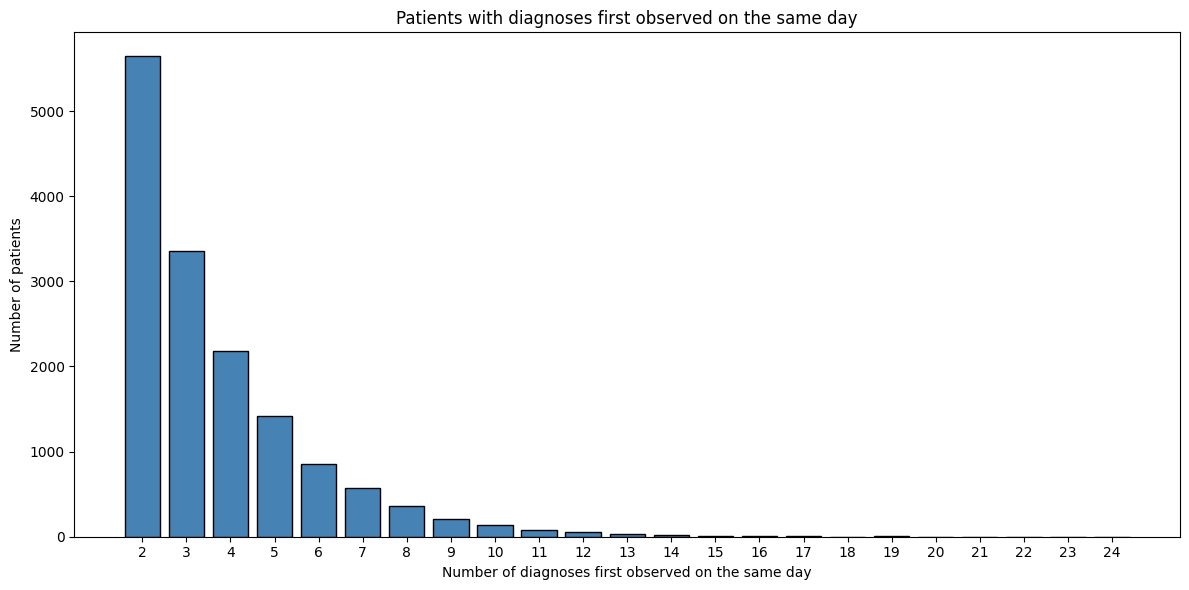

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    patient_distribution["n_same_day_diagnoses"],
    patient_distribution["n_patients"],
    color="steelblue",
    edgecolor="black"
)

plt.xlabel("Number of diagnoses first observed on the same day")
plt.ylabel("Number of patients")
plt.xticks(
    patient_distribution["n_same_day_diagnoses"]
)

plt.tight_layout()

plt.savefig(
    "sameDayDiagnosis.png",
    dpi=300,
    bbox_inches="tight"
)

In [124]:
patient_info = patient_filter[["patient_no", "sex_id", "sex", "age_group"]].drop_duplicates().copy()

patient_first_diag_sex_age = patient_first_diag.merge(
    patient_info,
    on="patient_no",
    how="left"
)

male_diag = patient_first_diag_sex_age[patient_first_diag_sex_age["sex"] == "Male"].copy()
female_diag = patient_first_diag_sex_age[patient_first_diag_sex_age["sex"] == "Female"].copy()


Instead of incidence matrix the hyperedge table is sorted, where for each patient from the previous table we add hyperedge index.

In [125]:
def build_hypergraph_tables(df):
    df = df.sort_values(["patient_no", "first_date", "node_id"]).copy()

    # One hyperedge = one patient
    df["hyperedge_index"] = df["patient_no"]

    # Hyperedge table: patient-diagnosis memberships
    hyperedge_table = df[
        [
            "hyperedge_index",
            "patient_no",
            "sex_id",
            "sex",
            "age_group",
            "node_id",
            "diagnose_id",
            "descr",
            "icd_code",
            "first_date"
        ]
    ].copy()

    # One row per patient with diagnosis sequence
    patient_sequences = (
        df.groupby(["patient_no", "hyperedge_index", "sex_id", "sex", "age_group"])
        .agg(
            sequence=("node_id", list),
            icd_sequence=("icd_code", list),
            first_date_sequence=("first_date", list),
            n_unique_diagnoses=("node_id", "nunique")
        )
        .reset_index()
    )

    return hyperedge_table, patient_sequences


In [126]:
male_hyperedge_table, male_sequences = build_hypergraph_tables(male_diag)
female_hyperedge_table, female_sequences = build_hypergraph_tables(female_diag)

SAVING PART

In [127]:
male_hyperedge_table.to_csv("male_hyperedge_table.csv", index=False)
female_hyperedge_table.to_csv("female_hyperedge_table.csv", index=False)
male_sequences.to_csv("male_sequences.csv", index=False)
female_sequences.to_csv("female_sequences.csv", index=False)